In [82]:
from sklearn.datasets import load_iris
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, DBSCAN
from sklearn.metrics import silhouette_score, confusion_matrix
from sklearn.decomposition import PCA
 
import pandas as pd
import matplotlib
import seaborn
import numpy

In [83]:
dataset = load_iris()
X = pd.DataFrame(dataset['data'], columns=dataset['feature_names'])
y = pd.Series(dataset['target'], name='target')

In [84]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

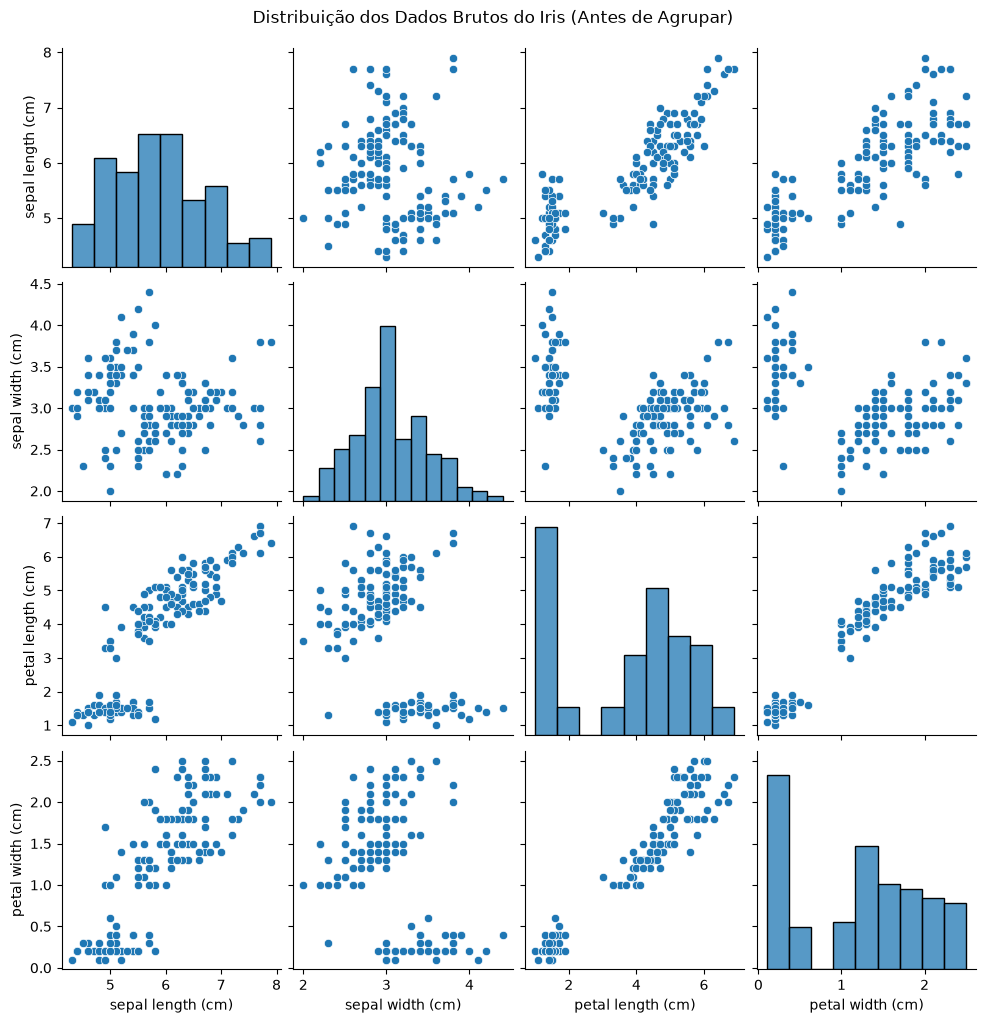

In [85]:
seaborn.pairplot(X)
matplotlib.pyplot.suptitle('Distribuição dos Dados Brutos do Iris (Antes de Agrupar)', y=1.02)
matplotlib.pyplot.show()

## Método do Cotovelo

In [86]:
inertias = []
k_range = range(1, 11)

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inertias.append(kmeans.inertia_)

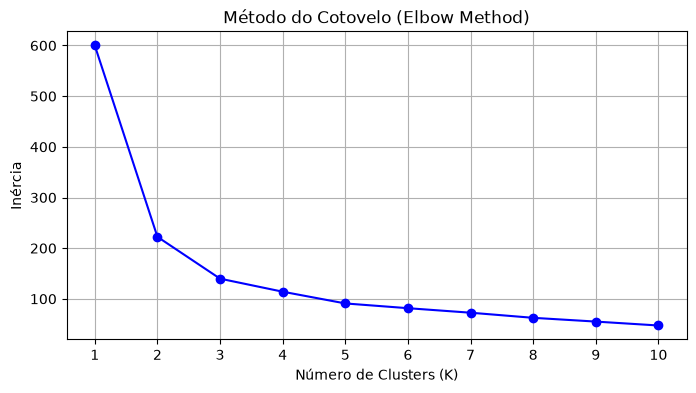

In [87]:
matplotlib.pyplot.figure(figsize=(8, 4))
matplotlib.pyplot.plot(k_range, inertias, 'bo-')
matplotlib.pyplot.title('Método do Cotovelo (Elbow Method)')
matplotlib.pyplot.xlabel('Número de Clusters (K)')
matplotlib.pyplot.ylabel('Inércia')
matplotlib.pyplot.xticks(k_range)
matplotlib.pyplot.grid(True)
matplotlib.pyplot.show()

## Método da Silhueta

In [89]:
silhouette_scores = []
k_range = range(2, 11)

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_scaled)
    score = silhouette_score(X_scaled, labels)
    silhouette_scores.append(score)

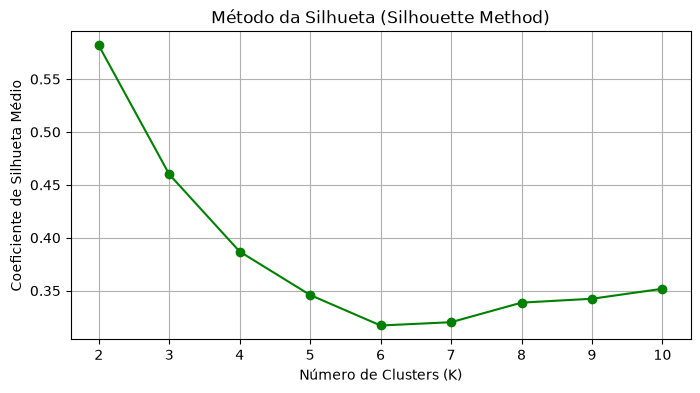

In [90]:
matplotlib.pyplot.figure(figsize=(8, 4))
matplotlib.pyplot.plot(k_range, silhouette_scores, 'go-')
matplotlib.pyplot.title('Método da Silhueta (Silhouette Method)')
matplotlib.pyplot.xlabel('Número de Clusters (K)')
matplotlib.pyplot.ylabel('Coeficiente de Silhueta Médio')
matplotlib.pyplot.xticks(k_range)
matplotlib.pyplot.grid(True)
matplotlib.pyplot.show()

## dbscan

In [91]:
dbscan = DBSCAN(eps=0.5, min_samples=4)
cluster_labels = dbscan.fit_predict(X_scaled)

In [92]:
unique_clusters = numpy.unique(cluster_labels)
n_clusters = len(unique_clusters[unique_clusters != -1])
n_noise = numpy.sum(cluster_labels == -1)

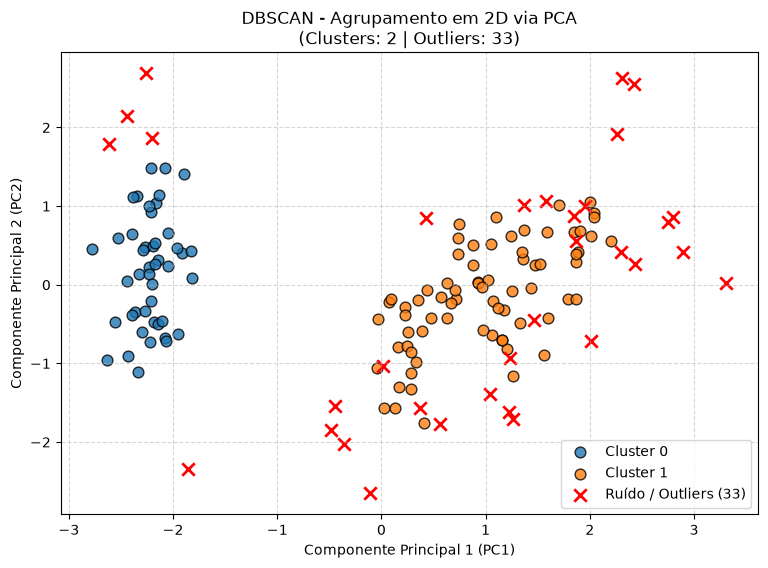

In [93]:
# Redução de 4 dimensões para 2
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

df_plot = pd.DataFrame(X_pca, columns=['PC1', 'PC2'])
df_plot['Cluster'] = cluster_labels

matplotlib.pyplot.figure(figsize=(9, 6))

# Plotar os clusters válidos
for cluster_id in range(n_clusters):
    cluster_data = df_plot[df_plot['Cluster'] == cluster_id]
    matplotlib.pyplot.scatter(
        cluster_data['PC1'], 
        cluster_data['PC2'], 
        label=f'Cluster {cluster_id}',
        s=60, 
        alpha=0.8,
        edgecolors='k'
    )

# Plotar ruídos/outliers (caso existam) com marcador 'X' vermelho
if n_noise > 0:
    noise_data = df_plot[df_plot['Cluster'] == -1]
    matplotlib.pyplot.scatter(
        noise_data['PC1'], 
        noise_data['PC2'], 
        color='red', 
        marker='x', 
        s=80, 
        linewidths=2,
        label=f'Ruído / Outliers ({n_noise})'
    )

matplotlib.pyplot.title(f'DBSCAN - Agrupamento em 2D via PCA\n(Clusters: {n_clusters} | Outliers: {n_noise})')
matplotlib.pyplot.xlabel('Componente Principal 1 (PC1)')
matplotlib.pyplot.ylabel('Componente Principal 2 (PC2)')
matplotlib.pyplot.legend(loc='best')
matplotlib.pyplot.grid(True, linestyle='--', alpha=0.5)
matplotlib.pyplot.show()